# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

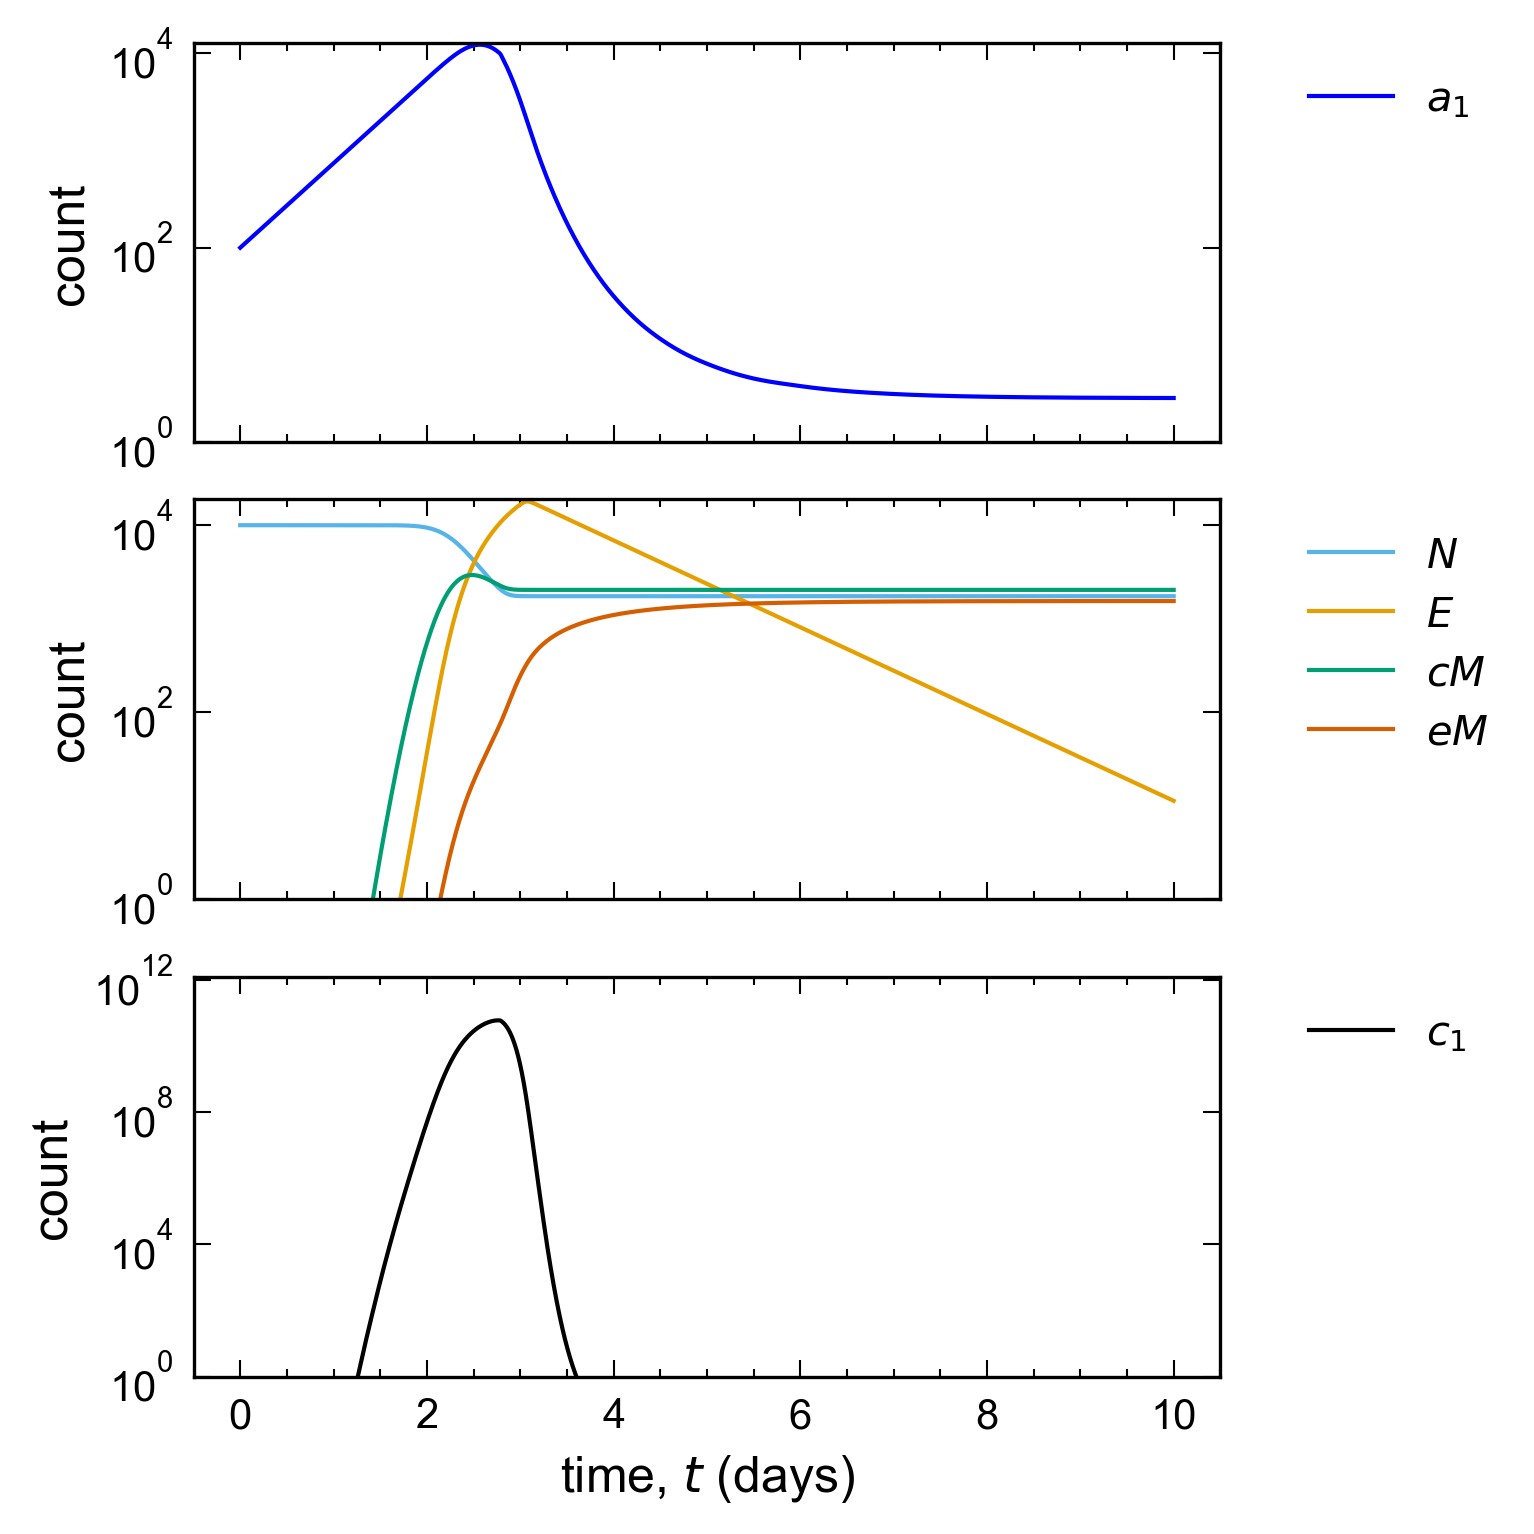

In [2]:
# Plot outputs
a1_0 = 100
b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
T_a1 = 10
infection_type = "prim" #"prim"

a1, N, E, cM, eM, T, ts = stoch_sim(a1_0, b_a1, t1, d_a1, 
                                    noise_model = "pop", 
                                    noise_cv = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                                    infection = infection_type)

fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))
#ax1.plot(ts, a1/a2, 'b', label = r'$\frac{a_1}{a_2}$')
ax1.plot(ts, a1, 'b', label = r'$a_1$')
ax1.set(ylabel='count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, cM, label = r'$cM$')
ax2.plot(ts, eM, label = r'$eM$')
ax2.set(ylabel='count')
ax2.set_ylim(1,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, c1_ss.py_func(t1,a1, E, T),'k-', label = r'$c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(a1, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(a1,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
ax3.semilogy()
ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig(infection_type+'-'+'virus-effector dynamics.pdf', dpi=300, bbox_inches="tight")

(1000, 5, 10001)


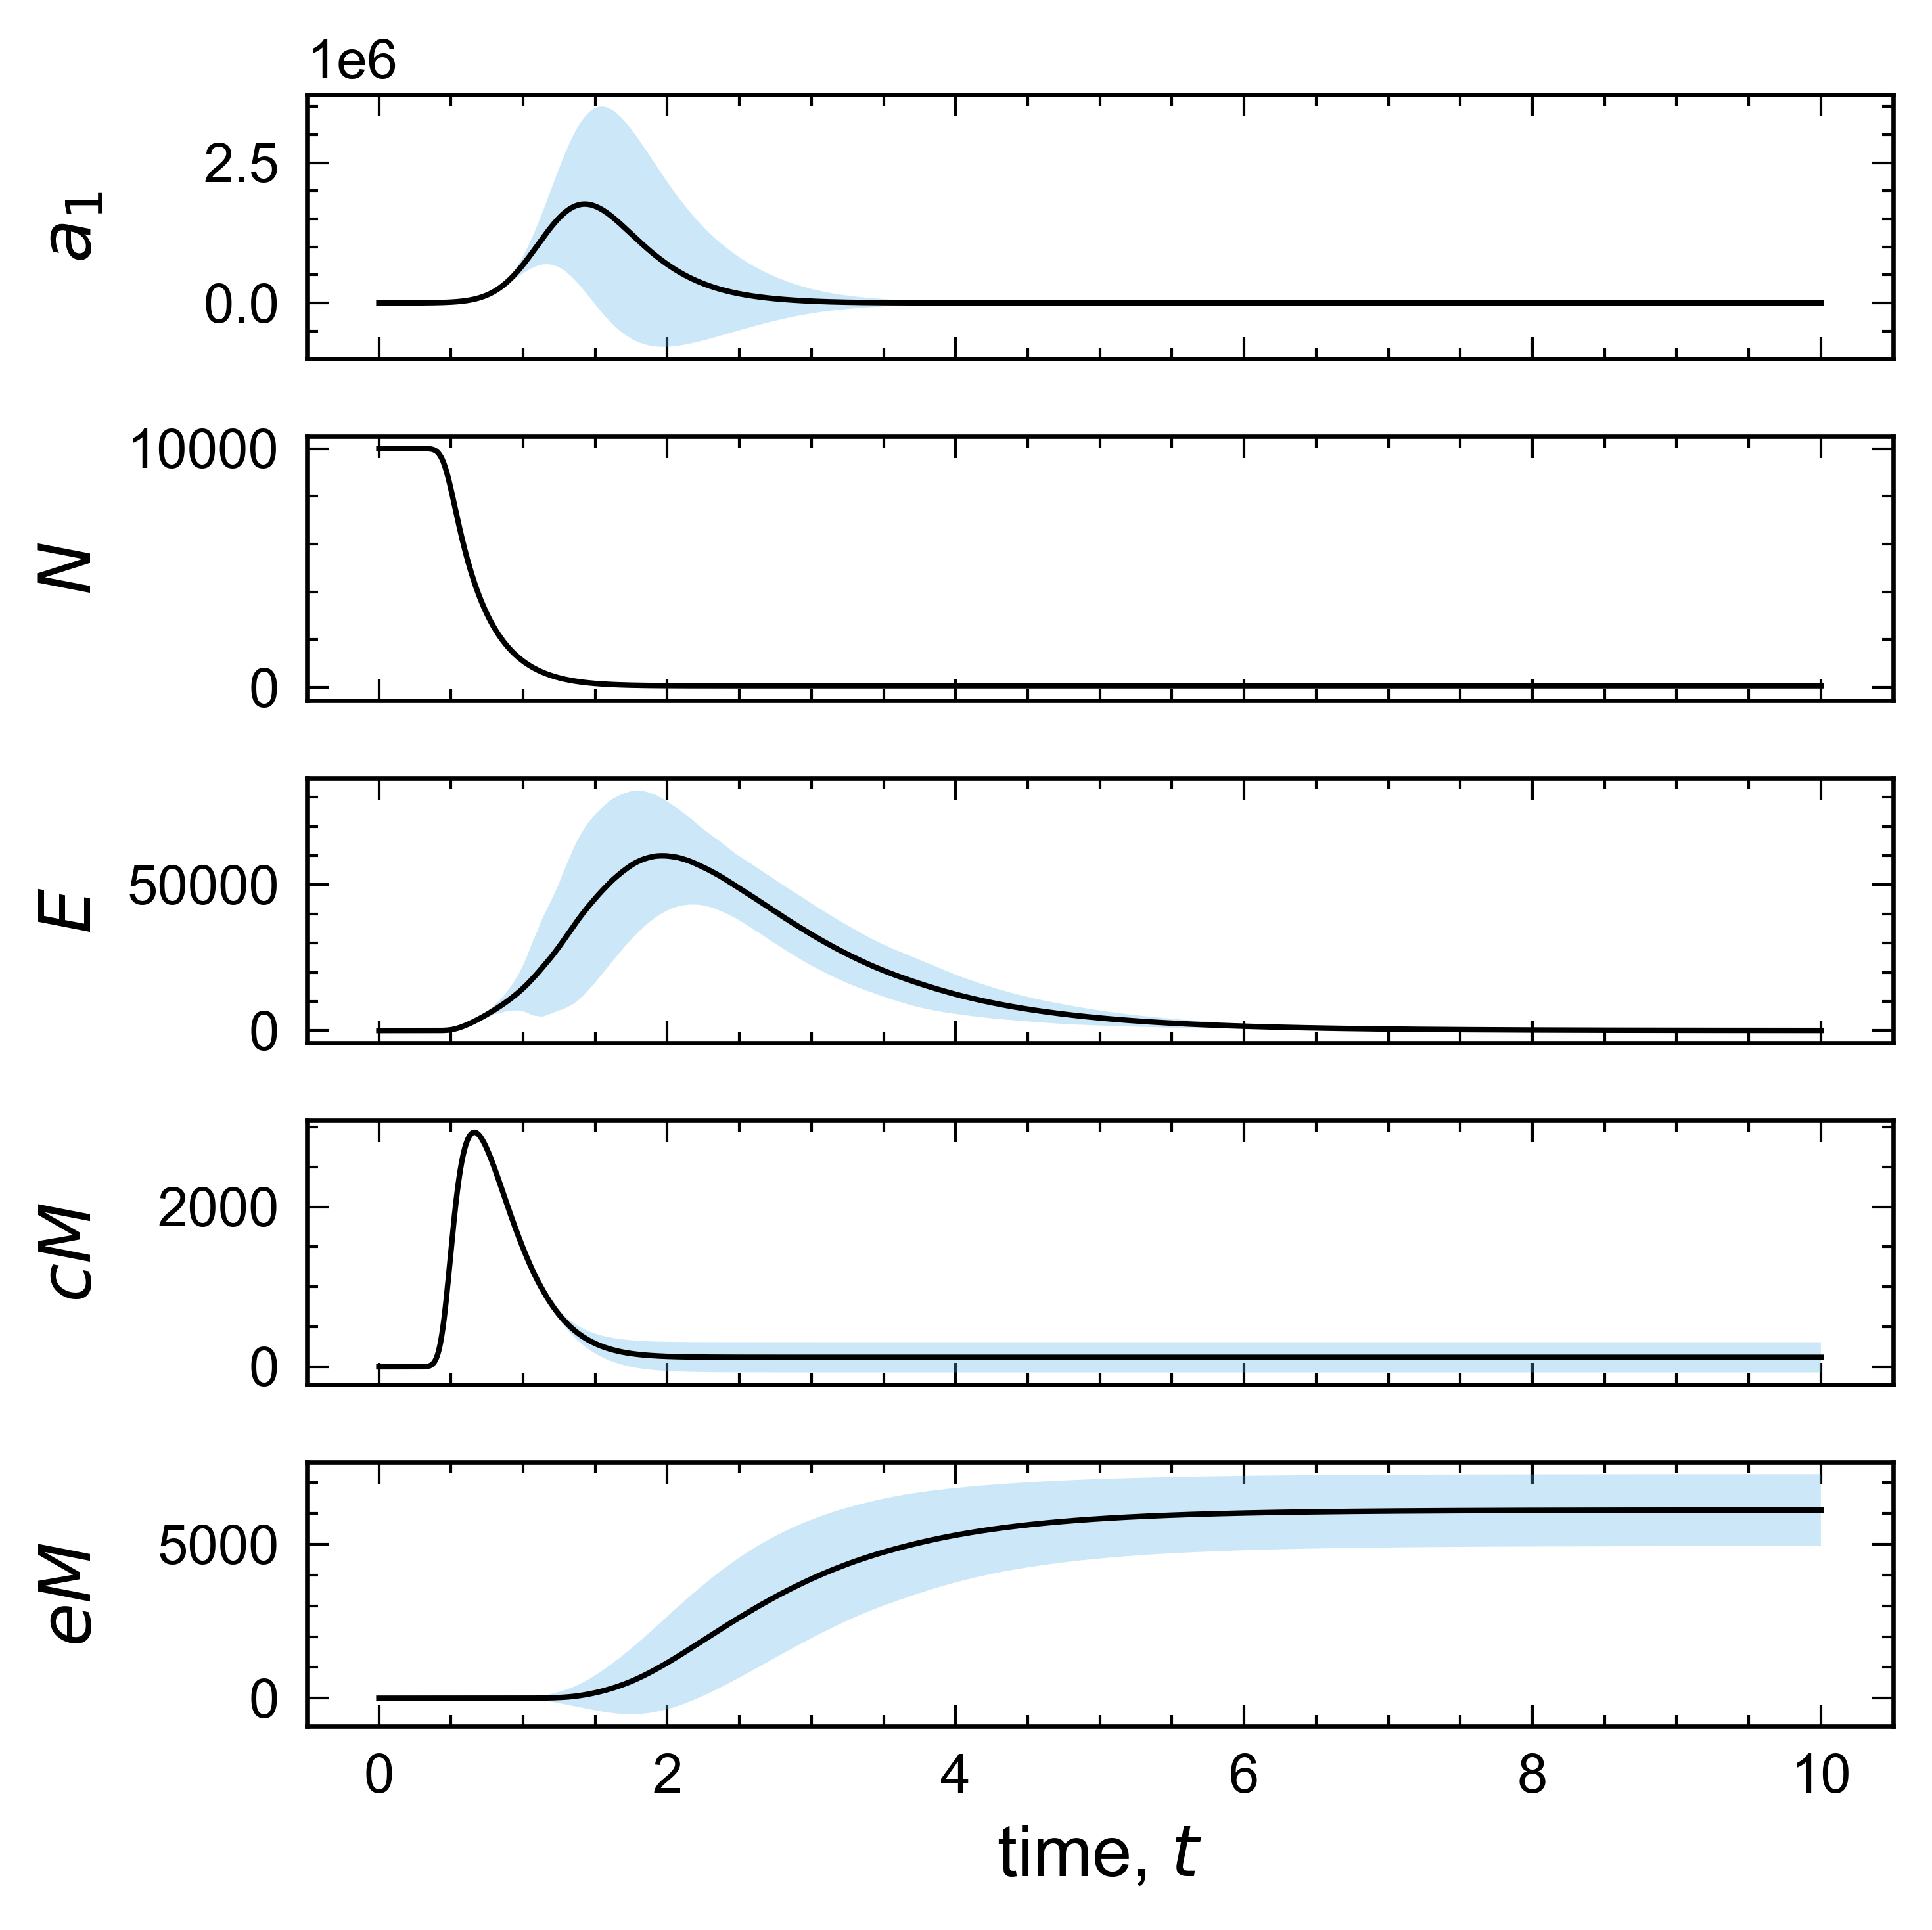

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5,5), sharex=True, dpi=300)

# This sets how many simulations are performed.
num_realizations = 1000
plot_labels = [r"$a_1$", r"$N$", r"$E$", r"$cM$", r"$eM$"]

trajectories = np.zeros(shape=(num_realizations, 5, steps+1))
for idx in range(num_realizations):
    a1, N, E, cM, eM, T, ts = stoch_sim(infection = infection_type)

    trajectories[idx] = a1, N, E, cM, eM
print(trajectories.shape)
# Filter out the entries in the numpy array which were full of zeros
# so they aren't plotted.
where_nonzero = np.count_nonzero(trajectories, axis=2).sum(axis=1) != 0
trajectories = trajectories[where_nonzero]

# Compute the mean and standard deviation over all the rows at each column.
# Plot the mean as a solid line and the mean +/- std as fill.
for states, ax in enumerate(axes):
    means = np.mean(trajectories[:,states,:], axis=0)
    stds = np.std(trajectories[:,states,:], axis=0)
    ax.plot(ts, means, 'k-')
    #ax.semilogy()
    ax.fill_between(ts, means - stds, means + stds, alpha=0.3)

# Make legend appear.
# for ax in axes:
#     ax.legend(fontsize=11, frameon=False, loc='upper right') #, bbox_to_anchor=(1.0,0.5))    

# Set xlabel.
for states, ax in enumerate(axes):
    if states == 4:
        ax.set_xlabel('time, $t$', fontsize=13)
    
# Set ylabels.
ylabels = plot_labels
for ax, ylabel in zip(axes, ylabels):
    ax.set_ylabel(ylabel, fontsize=13)

# Align y-axis labels.
fig.align_ylabels(axes)

fig.tight_layout()
plt.show()
fig.savefig(infection_type+'-'+'population-virus-effector dynamics.pdf', dpi=300, bbox_inches="tight")

## (2) Parallelize simulation runs

In [4]:
# Parallelize simulation runs

def for_parallel(a1_0, b_a1, t1, d_a1, 
                 noise_cv = [0.05, 0.0, 0.0, 0.0, 0.0, 0.0]):
    
    return sum_sim(a1_0, b_a1, t1, d_a1, noise_cv = noise_cv, infection = infection_type)

In [5]:
# Set global simulation parameters
runs = 10_0000

In [6]:
# run several simulations varying b_a1
cv_b_a1 = 0.5
#b_a1s = np.random.uniform(0.1*b_a1, 10*b_a1, size = runs) 
b_a1s = np.random.lognormal(mean = np.log(b_a1/np.sqrt(1 + cv_b_a1**2)), 
                            sigma = np.sqrt(np.log(1 + cv_b_a1**2)), size = runs)
t1s = [t1]
d_a1s = [d_a1]
T_a1s = [T_a1]
a1_0s = [a1_0]

run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s))

In [7]:
# run several simulations varying t1
cv_t1 = 0.1

b_a1s = [b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))
#t1s = np.random.uniform(t1, 2*t1, size = runs) 
t1s = np.random.lognormal(mean = np.log(t1/np.sqrt(1 + cv_t1**2)), 
                            sigma = np.sqrt(np.log(1 + cv_t1**2)), size = runs)
d_a1s = [d_a1]
T_a1s = [T_a1]
a1_0s = [a1_0]

run_data_t1 = np.nan_to_num(np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(t1s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s                                                  
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s)))

In [8]:
# run several simulations varying d_a1
cv_d_a1 = 0.5

b_a1s = [b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))
#d_a1s = np.random.uniform(0.1*d_a1, 10*d_a1, size = runs) 
t1s = [t1]
d_a1s = np.random.lognormal(mean = np.log(d_a1/np.sqrt(1 + cv_d_a1**2)), 
                            sigma = np.sqrt(np.log(1 + cv_d_a1**2)), size = runs)
T_a1s = [T_a1]
a1_0s = [a1_0]

run_data_d_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(d_a1s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s))

In [9]:
# run several simulations varying a1_0
cv_a1_0 = 0.5

b_a1s = [b_a1]
T_a1s = [T_a1]
#a1_0s = np.random.uniform(a1_0, 100*a1_0, size = runs) 
t1s = [t1]
d_a1s = [d_a1]
a1_0s = np.random.lognormal(mean = np.log(a1_0/np.sqrt(1 + cv_a1_0**2)), 
                            sigma = np.sqrt(np.log(1 + cv_a1_0**2)), size = runs)

run_data_a1_0 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(a1_0s)/8))(delayed(for_parallel)(a1_0, b_a1, t1, d_a1)
                                              for a1_0 in a1_0s
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s))

## (3) Plot distribution of response statistics from simulations varying $b_{a_1}$ and $t_1$

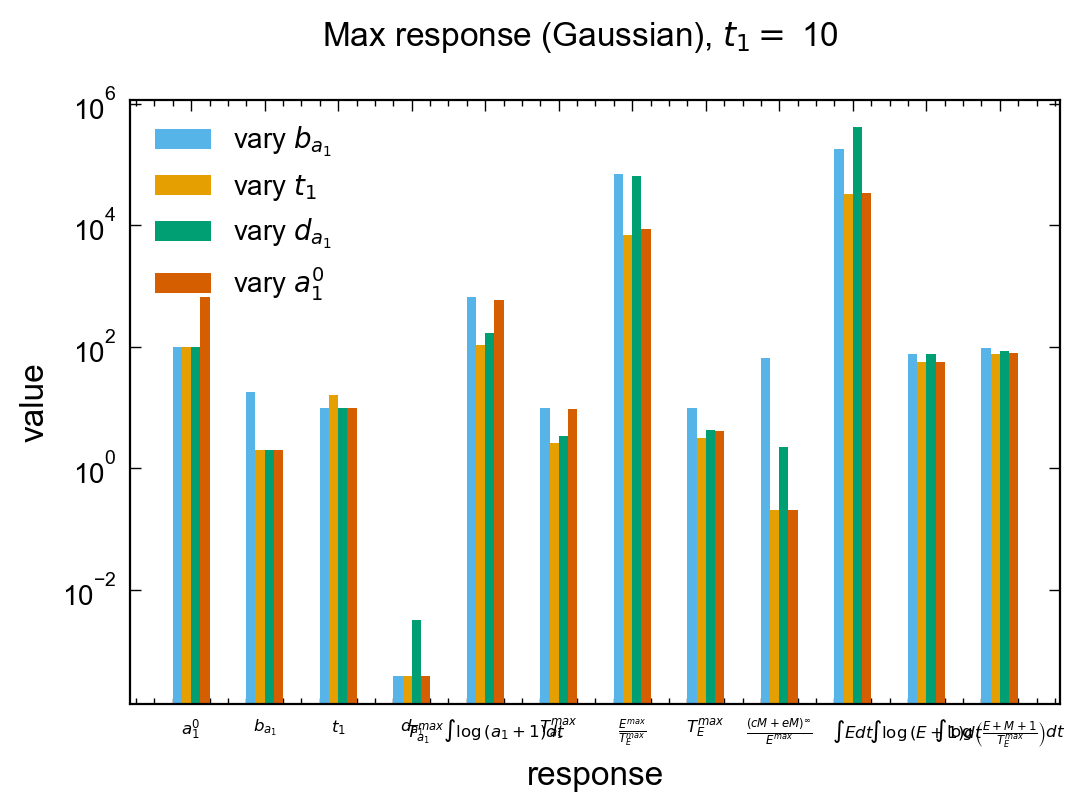

In [10]:
# Compute max values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amax(run_data_b_a1, axis = 0), width = width, label = r'vary $b_{a_1}$')
plt.bar(r + width, np.amax(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amax(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amax(run_data_a1_0, axis = 0), width = width, label = r'vary $a_{1}^0$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names, fontsize=6)

plt.semilogy()
plt.legend()
plt.suptitle(r'Max response (Gaussian), $t_1=$ '+str(t1))
plt.savefig(infection_type+'-'+'response-max-gauss-t1-'+str(t1)+'.png', dpi=150)

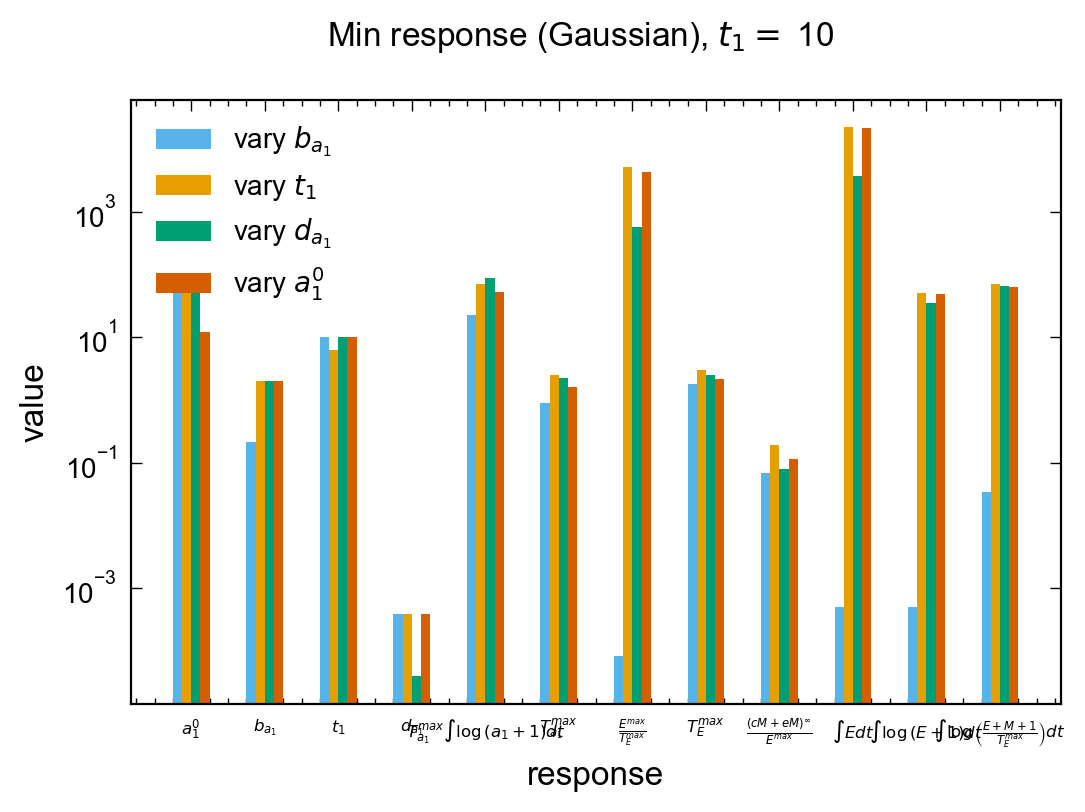

In [11]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amin(run_data_b_a1, axis = 0), width = width, label = r'vary $b_{a_1}$')
plt.bar(r + width, np.amin(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amin(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amin(run_data_a1_0, axis = 0), width = width, label = r'vary $a_{1}^0$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names, fontsize=6)

plt.semilogy()
plt.legend()
plt.suptitle(r'Min response (Gaussian), $t_1=$ '+str(t1))
plt.savefig(infection_type+'-'+'response-min-gauss-t1-'+str(t1)+'.png', dpi=150)

## (4) Compute mutual information between variables

In [12]:
# compute mutual information
MI_a1_0 = np.zeros(run_data_a1_0.shape[1])
for i in np.hstack(([0],np.arange(4,len(stat_names)))):
    MI_a1_0[i] = calc_MI(run_data_a1_0[:,0],run_data_a1_0[:,i])  

MI_b_a1 = np.zeros(run_data_b_a1.shape[1])
for i in np.hstack(([1],np.arange(4,len(stat_names)))):
    MI_b_a1[i] = calc_MI(run_data_b_a1[:,1],run_data_b_a1[:,i])

MI_t1 = np.zeros(run_data_t1.shape[1])
for i in np.hstack(([2],np.arange(4,len(stat_names)))):
    MI_t1[i] = calc_MI(run_data_t1[:,2],run_data_t1[:,i])
    
MI_d_a1 = np.zeros(run_data_d_a1.shape[1])
for i in np.hstack(([3],np.arange(4,len(stat_names)))):
    MI_d_a1[i] = calc_MI(run_data_d_a1[:,3],run_data_d_a1[:,i])

Text(0.5, 0.98, 'Entropy in generated data')

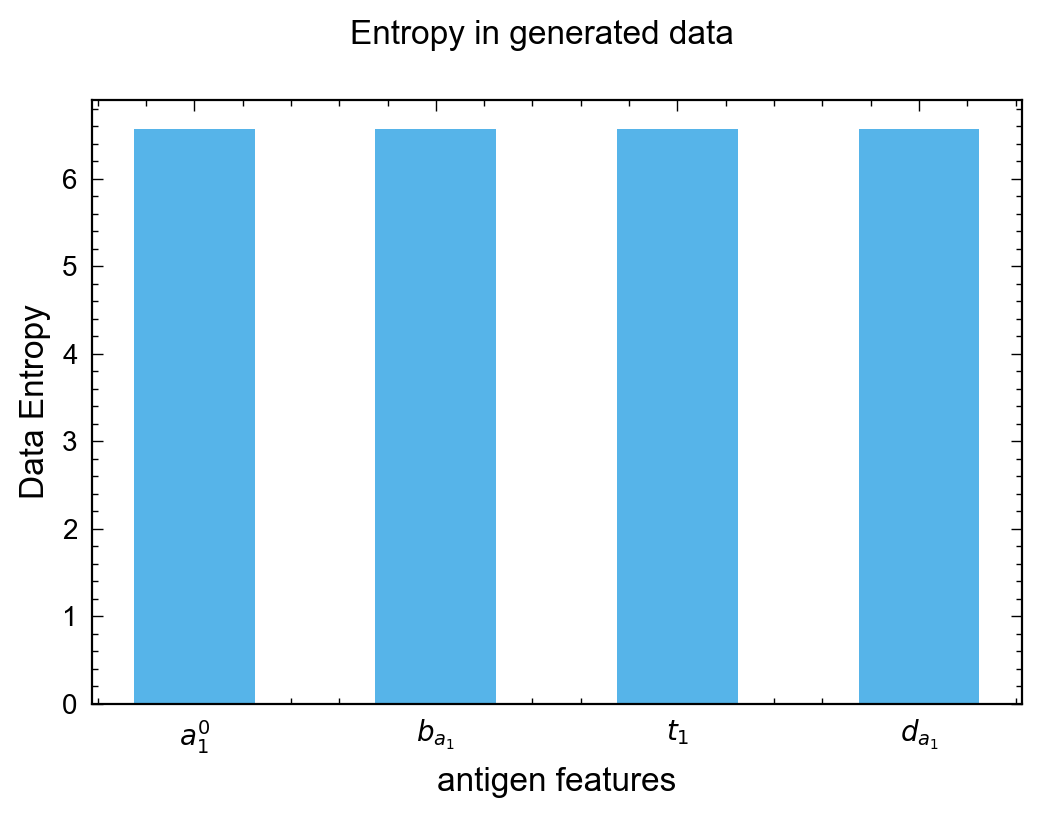

In [13]:
# Plot Data Entropy
plt.figure(1)

r = np.arange(4)
width = 0.5
plt.bar(r, np.array([MI_a1_0[0],MI_b_a1[1],MI_t1[2],MI_d_a1[3]]), width = width)

plt.xlabel("antigen features")
plt.ylabel("Data Entropy")

plt.xticks(r,stat_names[0:4])
plt.suptitle(r'Entropy in generated data')
#plt.savefig(infection_type+'-'+'response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150, bbox_inches="tight")

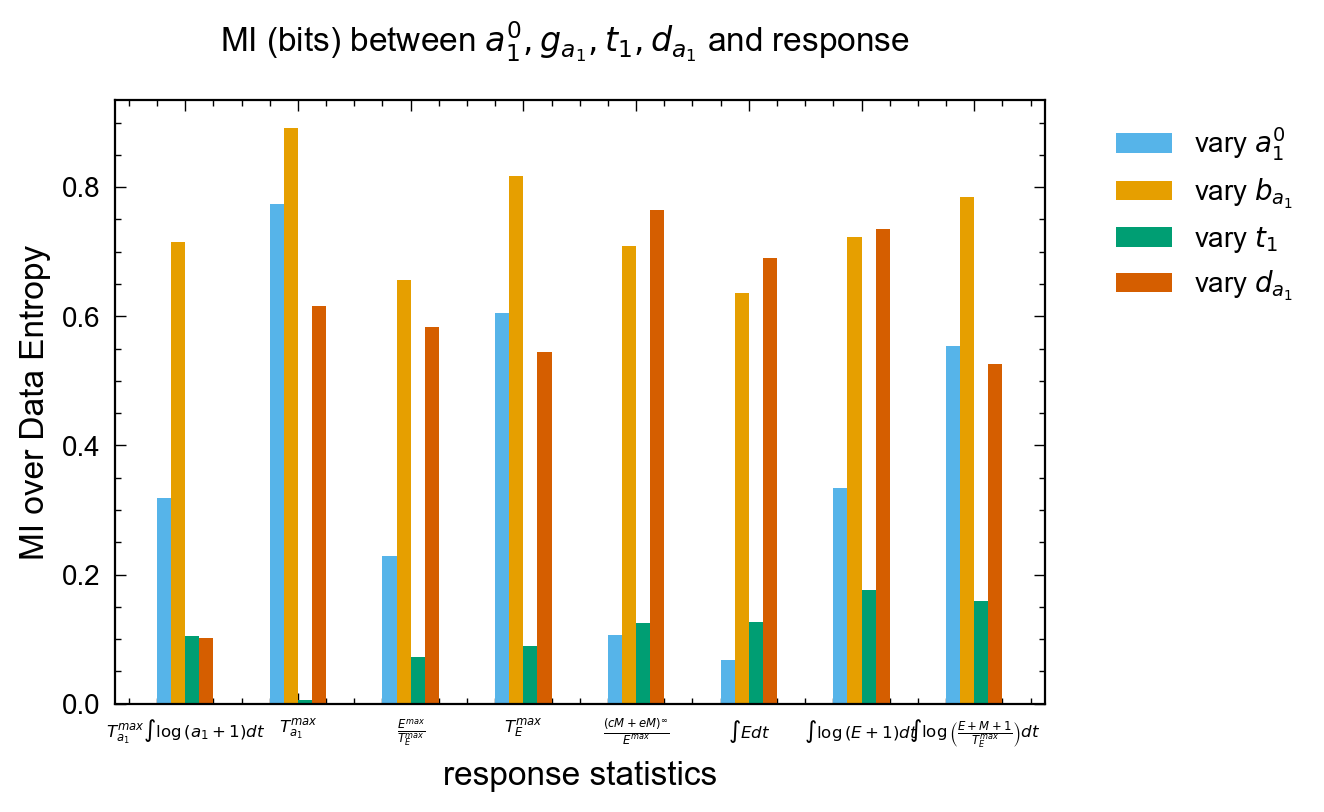

In [14]:
# Plot mutual information
plt.figure(1)

r = 2*np.arange(len(MI_b_a1[4:]))
width = 0.25
plt.bar(r, MI_a1_0[4:]/MI_a1_0[0], width = width, label = r'vary $a_{1}^0$')
plt.bar(r + width, MI_b_a1[4:]/MI_b_a1[1], width = width, label = r'vary $b_{a_1}$')
plt.bar(r + 2*width, MI_t1[4:]/MI_t1[2], width = width, label = r'vary $t_1$')
plt.bar(r + 3*width, MI_d_a1[4:]/MI_d_a1[3], width = width, label = r'vary $d_{a_1}$')

plt.xlabel("response statistics")
plt.ylabel("MI over Data Entropy")

plt.xticks(r + 3*width/2,stat_names[4:],fontsize=6)
#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle(r'MI (bits) between $a_1^0, g_{a_1}, t_1, d_{a_1}$ and response')
plt.savefig(infection_type+'-'+'response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150, bbox_inches="tight")

## (5) Plot trajectories from simulations

In [15]:
# Plot trajectories for b_a1

# fig_b_a1.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_b_a1.savefig('plot-response-varying-b_a1-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[4:]
xlabels = [stat_names[1]]*len(ylabels)

fig_b_a1 = joint_plot_grid([run_data_b_a1[:,1]]* len(ylabels), run_data_b_a1[:,4:].T.tolist(), granularity=50,
                use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_b_a1.savefig(infection_type+'-'+'plot-response-varying-b_a1-gauss-t1-'+str(t1)+'.png', dpi=150,bbox_inches="tight")


/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


In [16]:
# Plot trajectories for t1
# fig_t1.suptitle(r'Immune response while varying $t_1$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-t1-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[4:]
xlabels = [stat_names[2]]*len(ylabels)

fig_t1 = joint_plot_grid([run_data_t1[:,2]]*len(ylabels), run_data_t1[:,4:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_t1.savefig(infection_type+'-'+'plot-response-varying-t1-gauss-t1-'+str(t1)+'.png', dpi=150)

In [17]:
# Plot trajectories for d_a1
# fig_t1.suptitle(r'Immune response while varying $d_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-d_a1-gauss-t1-'+str(t1)+'.png', dpi=150)

ylabels=stat_names[4:]
xlabels = [stat_names[3]]*len(ylabels)

fig_d_a1 = joint_plot_grid([run_data_d_a1[:,3]]*len(ylabels), run_data_d_a1[:,4:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)
fig_d_a1.savefig(infection_type+'-'+'plot-response-varying-d_a1-gauss-t1-'+str(t1)+'.png', dpi=150)

In [18]:
# Plot trajectories for a1_0
# fig_t1.suptitle(r'Immune response while varying $a_1^0$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-a1_0-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[4:]
xlabels = [stat_names[0]]*len(ylabels)

fig_a1_0 = joint_plot_grid([run_data_a1_0[:,0]]*len(ylabels), run_data_a1_0[:,4:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_a1_0.savefig(infection_type+'-'+'plot-response-varying-a1_0-gauss-t1-'+str(t1)+'.png', dpi=150)
